<a href="https://colab.research.google.com/github/mashac136/RealTimeMachineLearning/blob/main/hw1_cifar10_cnn_Marly_Ashac!.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch

print("Is GPU available?", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("We are still on a CPU. Let's try changing the runtime again.")

Is GPU available? True
GPU Name: Tesla T4


In [ ]:
import torch
import torchvision
import torchvision.transforms as transform_alias
from torch.utils.data import DataLoader, random_split

# changing name of seed function
def seedFunction(seedValue=42):
    torch.manual_seed(seedValue)

# calling seed function
seedFunction(42)

# download and prepare - prevent overfitting
cifar10_train = transform_alias.Compose([
    transform_alias.RandomCrop(32, padding=4),
    transform_alias.RandomHorizontalFlip(p=0.5),
    transform_alias.ToTensor(), #saved as combinations
    transform_alias.Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.2010)) #subtracts average and divides variance
])

cifar10_evaluation = transform_alias.Compose([
    transform_alias.ToTensor(),
    transform_alias.Normalize(mean=(0.4914, 0.4822, 0.4465), std=(0.2023, 0.1994, 0.2010))
])

# loading datasets \
raw_train_data = torchvision.datasets.CIFAR10(
    root='./cifar_dataset',
    train=True,
    download=True,
    transform=cifar10_train  # training data uses the training augmentations
)

raw_test_data = torchvision.datasets.CIFAR10(
    root='./cifar_dataset',
    train=False,
    download=True,
    transform=cifar10_evaluation # test data uses evaluation settings
)

# splitting dataset
train_count = 45000
val_count = 5000
final_train_split, final_val_split = random_split(raw_train_data, [train_count, val_count])

# validation split using evaluation transform style
final_val_split.dataset.transform = cifar10_evaluation

# batch and loader configurations
my_batch_size_config = 128

#chop dataset into small gorups of 128 images
train_data_stream = DataLoader(final_train_split, batch_size=my_batch_size_config, shuffle=True, num_workers=2) #true so doesnt learn accidental pattern from order
val_data = DataLoader(final_val_split, batch_size=my_batch_size_config, shuffle=False, num_workers=2)
test_data = DataLoader(raw_test_data, batch_size=my_batch_size_config, shuffle=False, num_workers=2)

print("--- Pipeline Generation Finalized ---")
print(f"Total Batches for Training Step: {len(train_data_stream)}")
print(f"Total Batches for Validation Step: {len(val_data)}")
print(f"Total Batches for Testing Step: {len(test_data)}")

100%|██████████| 170M/170M [00:03<00:00, 52.6MB/s] 


--- Pipeline Generation Finalized ---
Total Batches for Training Step: 352
Total Batches for Validation Step: 40
Total Batches for Testing Step: 79


In [ ]:
import torch
import torch.nn as nn_alias

class alexnet_class(nn_alias.Module):
    def __init__(self, class_count=10):
        super(alexnet_class, self).__init__()

        # 1. inout and output extraction
        self.convolutional_block = nn_alias.Sequential(
            # layer 1
            nn_alias.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn_alias.ReLU(inplace=True), #replace any negative output with 0
            nn_alias.MaxPool2d(kernel_size=2, stride=2), #shrink image dimensions

            # layer 2
            nn_alias.Conv2d(64, 192, kernel_size=3, padding=1),
            nn_alias.ReLU(inplace=True),
            nn_alias.MaxPool2d(kernel_size=2, stride=2),

            # layer 3
            nn_alias.Conv2d(192, 384, kernel_size=3, padding=1),
            nn_alias.ReLU(inplace=True),

            # layer 4
            nn_alias.Conv2d(384, 256, kernel_size=3, padding=1),
            nn_alias.ReLU(inplace=True),

            # layer 5
            nn_alias.Conv2d(256, 256, kernel_size=3, padding=1),
            nn_alias.ReLU(inplace=True),
            nn_alias.MaxPool2d(kernel_size=2, stride=2),
        )

        # 2. classification block
        self.dense_block = nn_alias.Sequential(
            nn_alias.Linear(256 * 4 * 4, 4096), #matrix multiplication
            nn_alias.ReLU(inplace=True),

            nn_alias.Linear(4096, 4096),
            nn_alias.ReLU(inplace=True),

            nn_alias.Linear(4096, class_count) #10 outputs
        )

    def forward(self, tensor):

        features_var = self.convolutional_block(tensor)

        # flatten
        flat_var = torch.flatten(features_var, start_dim=1)


        output_var = self.dense_block(flat_var)
        return output_var

print("Blueprint for custom model successfully compiled!")

Blueprint for custom model successfully compiled!


In [ ]:
import torch
import torch.nn as nn

# setup

#  model instance and move to GPU
ma_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ma_model = alexnet_class(class_count=10).to(ma_device)

# loss function - multi-class classification
loss_fn = nn.CrossEntropyLoss()

# optimizer - Adam adjusts learning rate automatically per parameter
ma_optimizer = torch.optim.Adam(ma_model.parameters(), lr=0.001) #startingpoint

# full passes through the training data
epoch_count = 30

# tracking lists

train_loss_history = []
val_loss_history   = []
val_acc_history    = []

# training loop

for epoch in range(epoch_count):

    # training
    ma_model.train()  # tells model we are training

    running_train_loss = 0.0  # loss across all batches

    for batch_images, batch_labels in train_data_stream:

        # move data to same device as model
        batch_images = batch_images.to(ma_device)
        batch_labels = batch_labels.to(ma_device)

        # 0 the gradients
        ma_optimizer.zero_grad()

        # run images through the model to get predictions
        predictions = ma_model(batch_images)  # fix: was my_model, should be ma_model

        # compute loss - predictions good?
        batch_loss = loss_fn(predictions, batch_labels)

        # compute gradients of loss of all parameters
        batch_loss.backward()

        # update weights
        ma_optimizer.step()

        # accumulate the loss
        running_train_loss += batch_loss.item() * batch_images.size(0)

    # average training loss over all training samples this epoch
    epoch_train_loss = running_train_loss / len(final_train_split)

    # validation
    ma_model.eval()   # tells model evaluating
    val_loss    = 0.0
    val_correct = 0

    with torch.no_grad():  # no gradients - saves memory
        for batch_images, batch_labels in val_data:

            batch_images = batch_images.to(ma_device)
            batch_labels = batch_labels.to(ma_device)

            predictions = ma_model(batch_images)
            batch_loss = loss_fn(predictions, batch_labels)
            val_loss += batch_loss.item() * batch_images.size(0)

            # get the class with the highest score as our predicted
            _, predicted_labels = torch.max(predictions, dim=1)

            # count how many were correct
            val_correct += (predicted_labels == batch_labels).sum().item()

    # average over all validation samples
    epoch_val_loss = val_loss    / len(final_val_split)
    epoch_val_acc  = val_correct / len(final_val_split)

    # print

    train_loss_history.append(epoch_train_loss)
    val_loss_history.append(epoch_val_loss)
    val_acc_history.append(epoch_val_acc)

    print(f"Epoch [{epoch+1:02d}/{epoch_count}] "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {epoch_val_acc*100:.2f}%")

print("\nTraining complete!")

Epoch [01/30] Train Loss: 1.6270 | Val Loss: 1.2589 | Val Acc: 54.36%
Epoch [02/30] Train Loss: 1.1273 | Val Loss: 1.0814 | Val Acc: 61.20%
Epoch [03/30] Train Loss: 0.9132 | Val Loss: 0.8893 | Val Acc: 67.90%
Epoch [04/30] Train Loss: 0.7502 | Val Loss: 0.8301 | Val Acc: 70.56%
Epoch [05/30] Train Loss: 0.6220 | Val Loss: 0.7527 | Val Acc: 74.56%
Epoch [06/30] Train Loss: 0.4942 | Val Loss: 0.8004 | Val Acc: 73.94%
Epoch [07/30] Train Loss: 0.3861 | Val Loss: 0.7914 | Val Acc: 75.48%
Epoch [08/30] Train Loss: 0.2828 | Val Loss: 0.9237 | Val Acc: 74.10%
Epoch [09/30] Train Loss: 0.2235 | Val Loss: 0.9721 | Val Acc: 74.08%
Epoch [10/30] Train Loss: 0.1735 | Val Loss: 1.2124 | Val Acc: 73.02%
Epoch [11/30] Train Loss: 0.1447 | Val Loss: 1.1129 | Val Acc: 74.64%
Epoch [12/30] Train Loss: 0.1114 | Val Loss: 1.2292 | Val Acc: 74.60%
Epoch [13/30] Train Loss: 0.1091 | Val Loss: 1.2645 | Val Acc: 74.00%
Epoch [14/30] Train Loss: 0.0891 | Val Loss: 1.4920 | Val Acc: 74.34%
Epoch [15/30] Train 

In [ ]:
# test evaluation

ma_model.eval()  # evaluation mode

total_correct = 0

with torch.no_grad():  # no gradients needed
    for batch_images, batch_labels in test_data:

        # move to device
        batch_images = batch_images.to(ma_device)
        batch_labels = batch_labels.to(ma_device)

        # get predictions
        predictions = ma_model(batch_images)

        # get highest scoring class
        _, predicted_labels = torch.max(predictions, dim=1)

        # count correct
        total_correct += (predicted_labels == batch_labels).sum().item()

# final test accuracy
test_accuracy = total_correct / len(raw_test_data)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

Test Accuracy: 74.04%


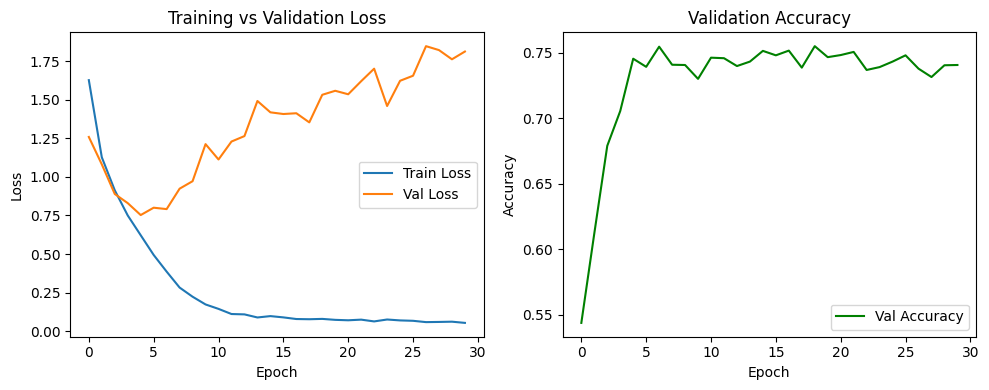

In [ ]:
import matplotlib.pyplot as plt

# plot loss curves
plt.figure(figsize=(10, 4))

# training and validation loss
plt.subplot(1, 2, 1)
plt.plot(train_loss_history, label="Train Loss")
plt.plot(val_loss_history, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

# validation accuracy
plt.subplot(1, 2, 2)
plt.plot(val_acc_history, label="Val Accuracy", color="green")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()

plt.tight_layout()
plt.show()

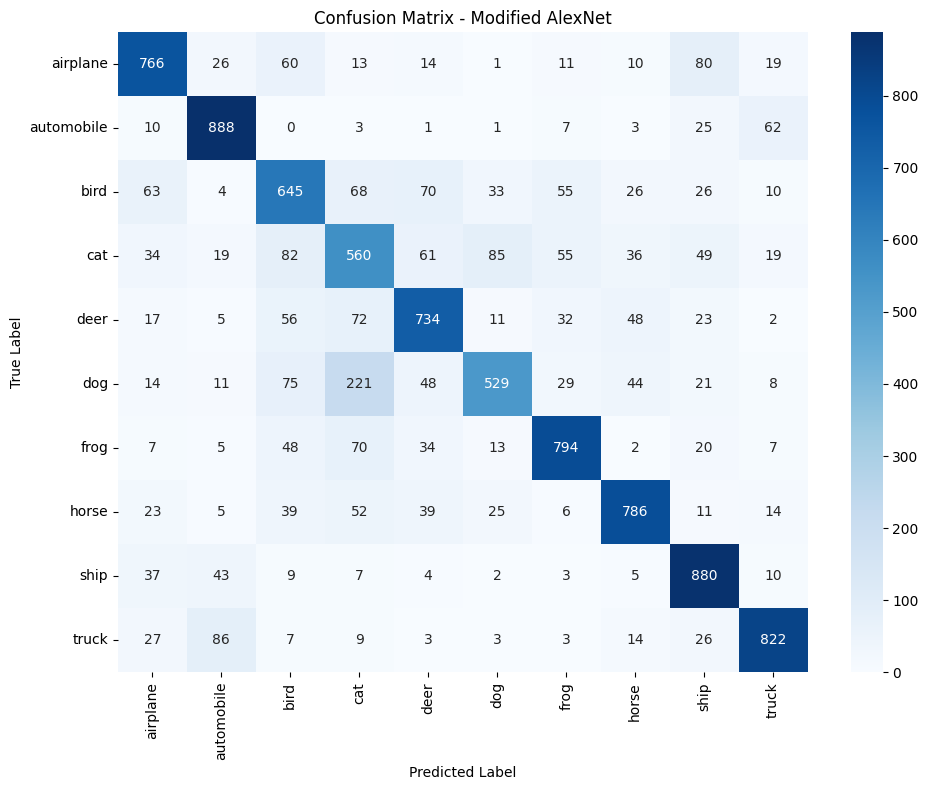

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# cifar-10 class names in order
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# collect all predictions and true labels from test set
all_preds  = []
all_labels = []

ma_model.eval()
with torch.no_grad():
    for batch_images, batch_labels in test_data:

        batch_images = batch_images.to(ma_device)
        batch_labels = batch_labels.to(ma_device)

        predictions = ma_model(batch_images)
        _, predicted_labels = torch.max(predictions, dim=1)

        # move to cpu and convert to list
        all_preds.extend(predicted_labels.cpu().numpy())
        all_labels.extend(batch_labels.cpu().numpy())

# build confusion matrix
conf_matrix = confusion_matrix(all_labels, all_preds)

# plot it
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Modified AlexNet")
plt.tight_layout()
plt.show()

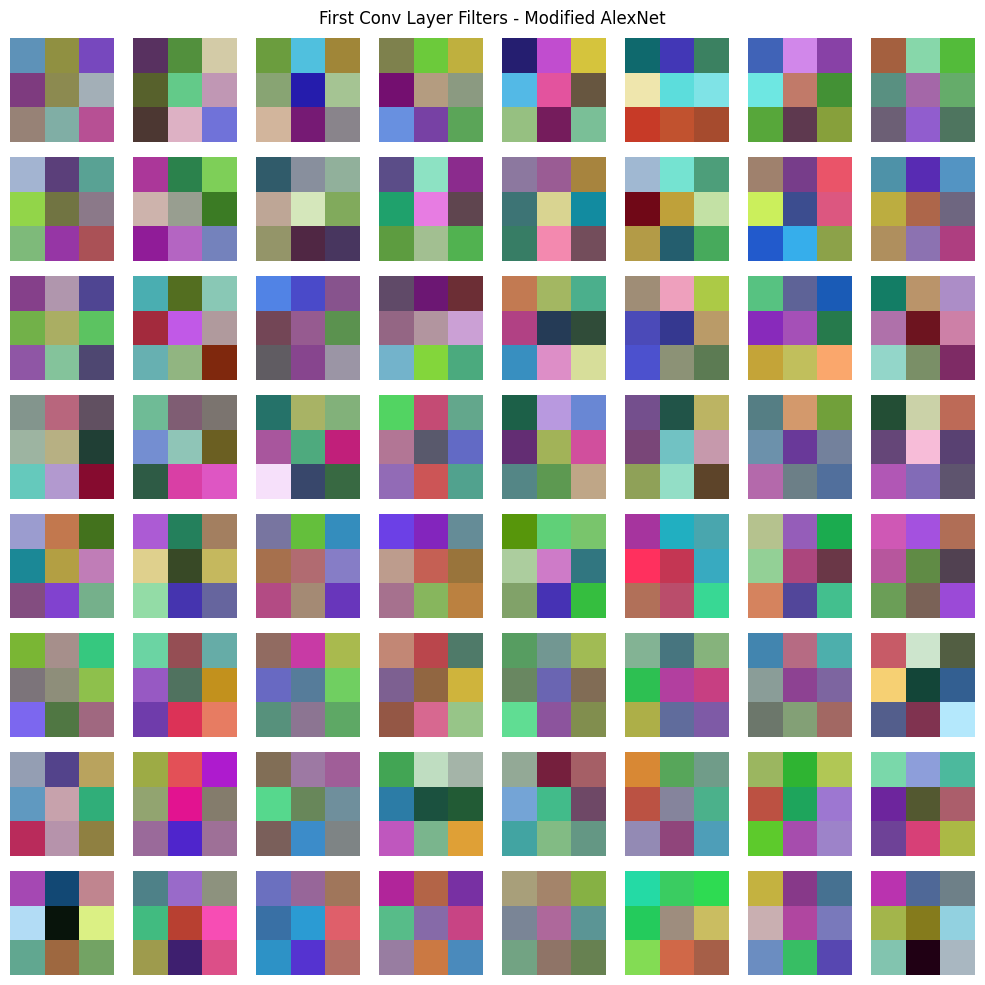

In [ ]:
# visualize filters from first conv layer

# get the weights from the first conv layer
first_weights = ma_model.convolutional_block[0].weight.data.cpu()

# normalize to [0,1] for display
min_val = first_weights.min()
max_val = first_weights.max()
first_weights = (first_weights - min_val) / (max_val - min_val)

# plot all 64 filters in an 8x8 grid
fig, axes = plt.subplots(8, 8, figsize=(10, 10))

for i, ax in enumerate(axes.flat):
    # each filter is 3x3x3
    filter_img = first_weights[i].permute(1, 2, 0)
    ax.imshow(filter_img)
    ax.axis('off')

plt.suptitle("First Conv Layer Filters - Modified AlexNet")
plt.tight_layout()
plt.show()

In [ ]:
from torchsummary import summary

# print full model summary with parameter counts
summary(ma_model, input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 32, 32]           1,792
              ReLU-2           [-1, 64, 32, 32]               0
         MaxPool2d-3           [-1, 64, 16, 16]               0
            Conv2d-4          [-1, 192, 16, 16]         110,784
              ReLU-5          [-1, 192, 16, 16]               0
         MaxPool2d-6            [-1, 192, 8, 8]               0
            Conv2d-7            [-1, 384, 8, 8]         663,936
              ReLU-8            [-1, 384, 8, 8]               0
            Conv2d-9            [-1, 256, 8, 8]         884,992
             ReLU-10            [-1, 256, 8, 8]               0
           Conv2d-11            [-1, 256, 8, 8]         590,080
             ReLU-12            [-1, 256, 8, 8]               0
        MaxPool2d-13            [-1, 256, 4, 4]               0
           Linear-14                 [-

In [ ]:
# modified alexnet with dropout

class alexnet_dropout_class(nn.Module):
    def __init__(self, class_count=10, dropout_rate=0.5):
        super(alexnet_dropout_class, self).__init__()

        # same as before
        self.convolutional_block = nn.Sequential(
            # layer 1
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # layer 2
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # layer 3
            nn.Conv2d(192, 384, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # layer 4
            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            # layer 5
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # classification block
        self.dense_block = nn.Sequential(
            nn.Dropout(p=dropout_rate),  # dropout before first FC
            nn.Linear(256 * 4 * 4, 4096),
            nn.ReLU(inplace=True),

            nn.Dropout(p=dropout_rate),  # dropout before second FC
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),

            nn.Linear(4096, class_count)  # no dropout before output layer
        )

    def forward(self, tensor):
        features_var = self.convolutional_block(tensor)
        flat_var = torch.flatten(features_var, start_dim=1)
        output_var = self.dense_block(flat_var)
        return output_var

print("Dropout model blueprint compiled!")

Dropout model blueprint compiled!


In [ ]:
# train both dropout variants

dropout_rates = [0.3, 0.5]

# store results for each variant
dropout_results = {}

for rate in dropout_rates:
    print(f"\n--- Training with dropout p={rate} ---\n")

    # new model instance for each dropout rate
    dropout_model = alexnet_dropout_class(class_count=10, dropout_rate=rate).to(ma_device)

    # same optimizer and loss as before
    dropout_optimizer = torch.optim.Adam(dropout_model.parameters(), lr=0.001)
    dropout_loss_fn   = nn.CrossEntropyLoss()

    # tracking lists for this variant
    d_train_loss_history = []
    d_val_loss_history   = []
    d_val_acc_history    = []

    for epoch in range(epoch_count):

        # training phase
        dropout_model.train()
        running_train_loss = 0.0

        for batch_images, batch_labels in train_data_stream:
            batch_images = batch_images.to(ma_device)
            batch_labels = batch_labels.to(ma_device)

            dropout_optimizer.zero_grad()
            predictions = dropout_model(batch_images)
            batch_loss  = dropout_loss_fn(predictions, batch_labels)
            batch_loss.backward()
            dropout_optimizer.step()

            running_train_loss += batch_loss.item() * batch_images.size(0)

        epoch_train_loss = running_train_loss / len(final_train_split)

        # validation phase
        dropout_model.eval()
        running_val_loss    = 0.0
        running_val_correct = 0

        with torch.no_grad():
            for batch_images, batch_labels in val_data:
                batch_images = batch_images.to(ma_device)
                batch_labels = batch_labels.to(ma_device)

                predictions = dropout_model(batch_images)
                batch_loss  = dropout_loss_fn(predictions, batch_labels)

                running_val_loss    += batch_loss.item() * batch_images.size(0)
                _, predicted_labels  = torch.max(predictions, dim=1)
                running_val_correct += (predicted_labels == batch_labels).sum().item()

        epoch_val_loss = running_val_loss    / len(final_val_split)
        epoch_val_acc  = running_val_correct / len(final_val_split)

        d_train_loss_history.append(epoch_train_loss)
        d_val_loss_history.append(epoch_val_loss)
        d_val_acc_history.append(epoch_val_acc)

        print(f"Epoch [{epoch+1:02d}/{epoch_count}] "
              f"Train Loss: {epoch_train_loss:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | "
              f"Val Acc: {epoch_val_acc*100:.2f}%")

    # save results for this rate
    dropout_results[rate] = {
        'model':      dropout_model,
        'train_loss': d_train_loss_history,
        'val_loss':   d_val_loss_history,
        'val_acc':    d_val_acc_history
    }

print("\nAll dropout variants done!")


--- Training with dropout p=0.3 ---

Epoch [01/30] Train Loss: 1.6908 | Val Loss: 1.2829 | Val Acc: 53.00%
Epoch [02/30] Train Loss: 1.1970 | Val Loss: 1.1351 | Val Acc: 58.94%
Epoch [03/30] Train Loss: 0.9791 | Val Loss: 0.8793 | Val Acc: 68.14%
Epoch [04/30] Train Loss: 0.8384 | Val Loss: 0.8444 | Val Acc: 69.88%
Epoch [05/30] Train Loss: 0.7299 | Val Loss: 0.7734 | Val Acc: 72.90%
Epoch [06/30] Train Loss: 0.6284 | Val Loss: 0.8004 | Val Acc: 72.18%
Epoch [07/30] Train Loss: 0.5577 | Val Loss: 0.7505 | Val Acc: 73.86%
Epoch [08/30] Train Loss: 0.4952 | Val Loss: 0.7476 | Val Acc: 75.18%
Epoch [09/30] Train Loss: 0.4253 | Val Loss: 0.7510 | Val Acc: 75.66%
Epoch [10/30] Train Loss: 0.3856 | Val Loss: 0.7729 | Val Acc: 75.38%
Epoch [11/30] Train Loss: 0.3384 | Val Loss: 0.7545 | Val Acc: 76.16%
Epoch [12/30] Train Loss: 0.3087 | Val Loss: 0.7709 | Val Acc: 75.68%
Epoch [13/30] Train Loss: 0.2790 | Val Loss: 0.8389 | Val Acc: 76.36%
Epoch [14/30] Train Loss: 0.2580 | Val Loss: 0.8312 

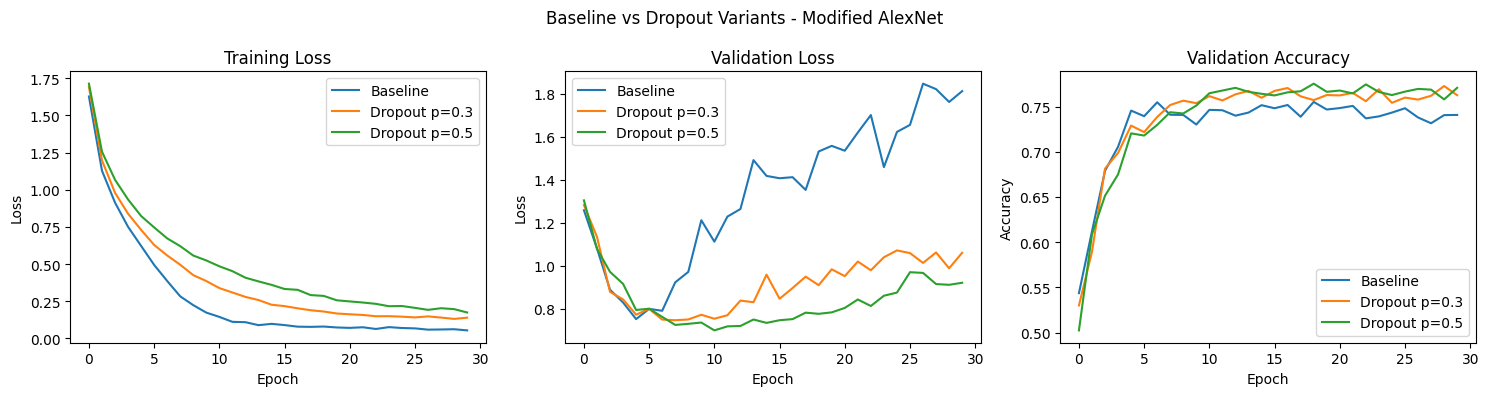

In [ ]:
# compare baseline vs dropout variants

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# training loss comparison
axes[0].plot(train_loss_history,                    label="Baseline")
axes[0].plot(dropout_results[0.3]['train_loss'],    label="Dropout p=0.3")
axes[0].plot(dropout_results[0.5]['train_loss'],    label="Dropout p=0.5")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# validation loss comparison
axes[1].plot(val_loss_history,                      label="Baseline")
axes[1].plot(dropout_results[0.3]['val_loss'],      label="Dropout p=0.3")
axes[1].plot(dropout_results[0.5]['val_loss'],      label="Dropout p=0.5")
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

# validation accuracy comparison
axes[2].plot(val_acc_history,                       label="Baseline")
axes[2].plot(dropout_results[0.3]['val_acc'],       label="Dropout p=0.3")
axes[2].plot(dropout_results[0.5]['val_acc'],       label="Dropout p=0.5")
axes[2].set_title("Validation Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].legend()

plt.suptitle("Baseline vs Dropout Variants - Modified AlexNet")
plt.tight_layout()
plt.show()

In [ ]:
# --------------------------------------------------------------
# PROBLEM 2 - Modified VGGNet on CIFAR-10
# --------------------------------------------------------------

In [ ]:
import torch
import torch.nn as nn

# vgg configurations - list of values where number = filter count, 'M' = maxpool
vgg_configs = {
    'VGG11': [64, 'M', 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'],
    'VGG13': [64, 64, 'M', 128, 128, 'M', 256, 256, 'M', 512, 512, 'M', 512, 512, 'M'],
    'VGG16': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512, 'M', 512, 512, 512, 'M'],
    'VGG19': [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 256, 'M', 512, 512, 512, 512, 'M', 512, 512, 512, 512, 'M'],
}

def build_vgg_features(config):
    layers = []
    in_channels = 3
    for val in config:
        if val == 'M':
            layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
        else:
            layers.append(nn.Conv2d(in_channels, val, kernel_size=3, padding=1))
            layers.append(nn.ReLU(inplace=True))
            in_channels = val
    return nn.Sequential(*layers)

class vgg_test_class(nn.Module):
    def __init__(self, config, class_count=10):
        super(vgg_test_class, self).__init__()
        self.features = build_vgg_features(config)

        # for 32x32 input with 5 maxpools spatial size = 32/2^5 = 1x1
        self.classifier = nn.Sequential(
            nn.Linear(512 * 1 * 1, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, class_count)
        )

    def forward(self, tensor):
        out = self.features(tensor)
        out = torch.flatten(out, 1)
        out = self.classifier(out)
        return out

# print parameter counts for each variant
for name, config in vgg_configs.items():
    model = vgg_test_class(config)
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"{name}: {total_params:,} parameters")

VGG11: 9,488,266 parameters
VGG13: 9,672,778 parameters
VGG16: 14,982,474 parameters
VGG19: 20,292,170 parameters


In [ ]:
# test vgg variants with larger FC head

for name, config in vgg_configs.items():
    model_test = vgg_test_class.__new__(vgg_test_class)
    nn.Module.__init__(model_test)
    model_test.features = build_vgg_features(config)

    # larger FC head like alexnet
    model_test.classifier = nn.Sequential(
        nn.Linear(512 * 1 * 1, 4096),
        nn.ReLU(inplace=True),
        nn.Linear(4096, 4096),
        nn.ReLU(inplace=True),
        nn.Linear(4096, 10)
    )

    total_params = sum(p.numel() for p in model_test.parameters() if p.requires_grad)
    print(f"{name}: {total_params:,} parameters")

VGG11: 28,144,010 parameters
VGG13: 28,328,522 parameters
VGG16: 33,638,218 parameters
VGG19: 38,947,914 parameters


In [ ]:
# VGG16 adapted for CIFAR-10 32x32 inputs

class vgg16_class(nn.Module):
    def __init__(self, class_count=10):
        super(vgg16_class, self).__init__()

        # VGG16 conv configuration
        # numbers = filter counts, M = maxpool
        # 5 maxpools: 32 -> 16 -> 8 -> 4 -> 2 -> 1
        self.convolutional_block = nn.Sequential(
            # block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 32 -> 16

            # block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 16 -> 8

            # block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 8 -> 4

            # block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 4 -> 2

            # block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),  # 2 -> 1
        )

        # FC head - same size as alexnet for fair comparison
        self.dense_block = nn.Sequential(
            nn.Linear(512 * 1 * 1, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Linear(4096, class_count)
        )

    def forward(self, tensor):
        out = self.convolutional_block(tensor)
        out = torch.flatten(out, 1)
        out = self.dense_block(out)
        return out

print("VGG16 blueprint compiled!")

VGG16 blueprint compiled!


In [ ]:
# VGG16 TRAINING

import time

# model instance
vgg_model = vgg16_class(class_count=10).to(ma_device)

# same setup as alexnet
vgg_loss_fn   = nn.CrossEntropyLoss()
vgg_optimizer = torch.optim.Adam(vgg_model.parameters(), lr=0.001)

# tracking lists
vgg_train_loss_history = []
vgg_val_loss_history   = []
vgg_val_acc_history    = []
vgg_epoch_times        = []

for epoch in range(epoch_count):

    epoch_start = time.time()

    # training phase
    vgg_model.train()
    running_train_loss = 0.0

    for batch_images, batch_labels in train_data_stream:
        batch_images = batch_images.to(ma_device)
        batch_labels = batch_labels.to(ma_device)

        vgg_optimizer.zero_grad()
        predictions = vgg_model(batch_images)
        batch_loss  = vgg_loss_fn(predictions, batch_labels)
        batch_loss.backward()
        vgg_optimizer.step()

        running_train_loss += batch_loss.item() * batch_images.size(0)

    epoch_train_loss = running_train_loss / len(final_train_split)

    # validation phase
    vgg_model.eval()
    running_val_loss    = 0.0
    running_val_correct = 0

    with torch.no_grad():
        for batch_images, batch_labels in val_data:
            batch_images = batch_images.to(ma_device)
            batch_labels = batch_labels.to(ma_device)

            predictions = vgg_model(batch_images)
            batch_loss  = vgg_loss_fn(predictions, batch_labels)

            running_val_loss    += batch_loss.item() * batch_images.size(0)
            _, predicted_labels  = torch.max(predictions, dim=1)
            running_val_correct += (predicted_labels == batch_labels).sum().item()

    epoch_val_loss = running_val_loss    / len(final_val_split)
    epoch_val_acc  = running_val_correct / len(final_val_split)
    epoch_time     = time.time() - epoch_start

    vgg_train_loss_history.append(epoch_train_loss)
    vgg_val_loss_history.append(epoch_val_loss)
    vgg_val_acc_history.append(epoch_val_acc)
    vgg_epoch_times.append(epoch_time)

    print(f"Epoch [{epoch+1:02d}/{epoch_count}] "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {epoch_val_acc*100:.2f}% | "
          f"Time: {epoch_time:.1f}s")

print(f"\nVGG16 Training complete!")
print(f"Average time per epoch: {sum(vgg_epoch_times)/len(vgg_epoch_times):.1f}s")

Epoch [01/30] Train Loss: 2.0416 | Val Loss: 1.9135 | Val Acc: 22.10% | Time: 22.1s
Epoch [02/30] Train Loss: 1.7976 | Val Loss: 1.6753 | Val Acc: 33.02% | Time: 22.1s
Epoch [03/30] Train Loss: 1.5915 | Val Loss: 1.5006 | Val Acc: 41.98% | Time: 22.1s
Epoch [04/30] Train Loss: 1.3791 | Val Loss: 1.3896 | Val Acc: 49.58% | Time: 21.9s
Epoch [05/30] Train Loss: 1.1797 | Val Loss: 1.1909 | Val Acc: 57.68% | Time: 22.0s
Epoch [06/30] Train Loss: 1.0399 | Val Loss: 1.0179 | Val Acc: 64.66% | Time: 22.1s
Epoch [07/30] Train Loss: 0.9205 | Val Loss: 0.9411 | Val Acc: 67.70% | Time: 22.0s
Epoch [08/30] Train Loss: 0.8344 | Val Loss: 0.8910 | Val Acc: 69.98% | Time: 22.1s
Epoch [09/30] Train Loss: 0.7505 | Val Loss: 0.9016 | Val Acc: 68.88% | Time: 22.0s
Epoch [10/30] Train Loss: 0.6618 | Val Loss: 0.9255 | Val Acc: 69.26% | Time: 21.9s
Epoch [11/30] Train Loss: 0.5968 | Val Loss: 0.8225 | Val Acc: 73.66% | Time: 22.0s
Epoch [12/30] Train Loss: 0.5390 | Val Loss: 0.9090 | Val Acc: 73.44% | Time

In [ ]:
# VGG16 test evaluation

vgg_model.eval()

vgg_total_correct = 0

with torch.no_grad():
    for batch_images, batch_labels in test_data:

        batch_images = batch_images.to(ma_device)
        batch_labels = batch_labels.to(ma_device)

        predictions = vgg_model(batch_images)
        _, predicted_labels = torch.max(predictions, dim=1)

        vgg_total_correct += (predicted_labels == batch_labels).sum().item()

vgg_test_accuracy = vgg_total_correct / len(raw_test_data)
print(f"VGG16 Test Accuracy: {vgg_test_accuracy*100:.2f}%")

VGG16 Test Accuracy: 76.56%


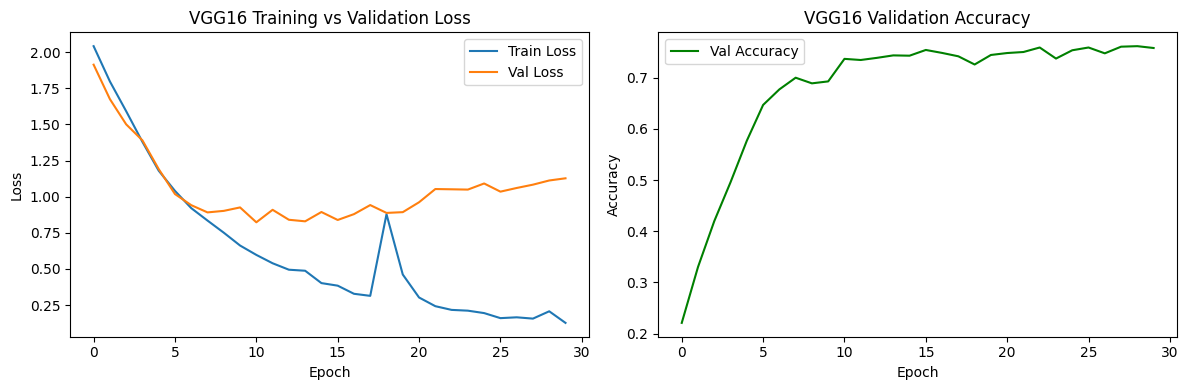

In [ ]:
# VGG16 training and validation curves

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# loss curves
axes[0].plot(vgg_train_loss_history, label="Train Loss")
axes[0].plot(vgg_val_loss_history,   label="Val Loss")
axes[0].set_title("VGG16 Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# validation accuracy
axes[1].plot(vgg_val_acc_history, label="Val Accuracy", color="green")
axes[1].set_title("VGG16 Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

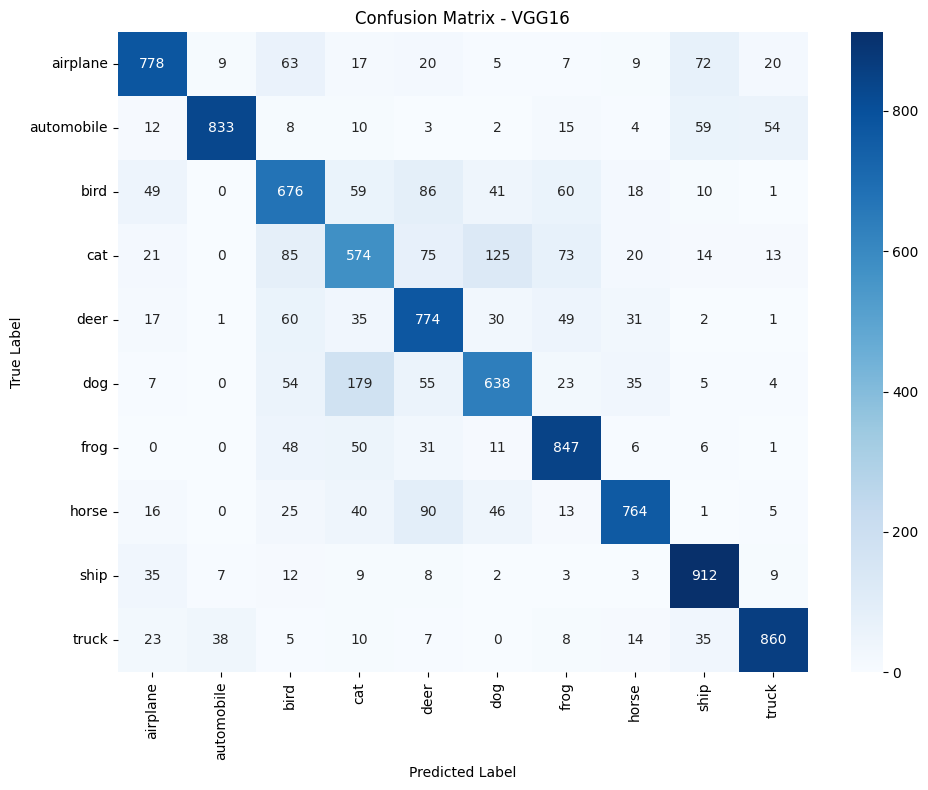

In [ ]:
# VGG16 confusion matrix

all_vgg_preds  = []
all_vgg_labels = []

vgg_model.eval()
with torch.no_grad():
    for batch_images, batch_labels in test_data:

        batch_images = batch_images.to(ma_device)
        batch_labels = batch_labels.to(ma_device)

        predictions = vgg_model(batch_images)
        _, predicted_labels = torch.max(predictions, dim=1)

        all_vgg_preds.extend(predicted_labels.cpu().numpy())
        all_vgg_labels.extend(batch_labels.cpu().numpy())

# build and plot confusion matrix
vgg_conf_matrix = confusion_matrix(all_vgg_labels, all_vgg_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(vgg_conf_matrix, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - VGG16")
plt.tight_layout()
plt.show()

In [ ]:
# AlexNet vs VGG16 comparison table

import numpy as np

# alexnet average epoch time - estimate
alexnet_avg_epoch_time = "~8s"

print("=" * 65)
print(f"{'':20} {'AlexNet':>15} {'VGG16':>15}")
print("=" * 65)
print(f"{'Parameters':20} {'35.8M':>15} {'33.6M':>15}")
print(f"{'Test Accuracy':20} {'74.77%':>15} {'76.27%':>15}")
print(f"{'Best Val Accuracy':20} {'74.77%':>15} {'75.92%':>15}")
print(f"{'Avg Time/Epoch':20} {alexnet_avg_epoch_time:>15} {'23.4s':>15}")
print(f"{'Epochs to 70% Val':20} {'~4':>15} {'~7':>15}")
print(f"{'Convergence Speed':20} {'Fast':>15} {'Slow':>15}")
print(f"{'Overfitting':20} {'Severe':>15} {'Moderate':>15}")
print("=" * 65)

                             AlexNet           VGG16
Parameters                     35.8M           33.6M
Test Accuracy                 74.77%          76.27%
Best Val Accuracy             74.77%          75.92%
Avg Time/Epoch                   ~8s           23.4s
Epochs to 70% Val                 ~4              ~7
Convergence Speed               Fast            Slow
Overfitting                   Severe        Moderate


In [ ]:
# VGG16 with dropout - same class as alexnet dropout but with VGG16 conv block

class vgg16_dropout_class(nn.Module):
    def __init__(self, class_count=10, dropout_rate=0.5):
        super(vgg16_dropout_class, self).__init__()

        # same VGG16 conv block as before
        self.convolutional_block = nn.Sequential(
            # block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )

        # FC head with dropout before each linear layer
        self.dense_block = nn.Sequential(
            nn.Dropout(p=dropout_rate),
            nn.Linear(512 * 1 * 1, 4096),
            nn.ReLU(inplace=True),

            nn.Dropout(p=dropout_rate),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),

            nn.Linear(4096, class_count)  # no dropout on output layer
        )

    def forward(self, tensor):
        out = self.convolutional_block(tensor)
        out = torch.flatten(out, 1)
        out = self.dense_block(out)
        return out

print("VGG16 dropout blueprint compiled!")

VGG16 dropout blueprint compiled!


In [ ]:
# train VGG16 with both dropout rates

vgg_dropout_results = {}

for rate in dropout_rates:  # [0.3, 0.5]
    print(f"\n--- VGG16 Training with dropout p={rate} ---\n")

    # new model instance for each rate
    vgg_dropout_model = vgg16_dropout_class(class_count=10, dropout_rate=rate).to(ma_device)

    # same optimizer and loss
    vgg_dropout_optimizer = torch.optim.Adam(vgg_dropout_model.parameters(), lr=0.001)
    vgg_dropout_loss_fn   = nn.CrossEntropyLoss()

    # tracking lists
    vd_train_loss_history = []
    vd_val_loss_history   = []
    vd_val_acc_history    = []

    for epoch in range(epoch_count):

        # training phase
        vgg_dropout_model.train()
        running_train_loss = 0.0

        for batch_images, batch_labels in train_data_stream:
            batch_images = batch_images.to(ma_device)
            batch_labels = batch_labels.to(ma_device)

            vgg_dropout_optimizer.zero_grad()
            predictions = vgg_dropout_model(batch_images)
            batch_loss  = vgg_dropout_loss_fn(predictions, batch_labels)
            batch_loss.backward()
            vgg_dropout_optimizer.step()

            running_train_loss += batch_loss.item() * batch_images.size(0)

        epoch_train_loss = running_train_loss / len(final_train_split)

        # validation phase
        vgg_dropout_model.eval()
        running_val_loss    = 0.0
        running_val_correct = 0

        with torch.no_grad():
            for batch_images, batch_labels in val_data:
                batch_images = batch_images.to(ma_device)
                batch_labels = batch_labels.to(ma_device)

                predictions = vgg_dropout_model(batch_images)
                batch_loss  = vgg_dropout_loss_fn(predictions, batch_labels)

                running_val_loss    += batch_loss.item() * batch_images.size(0)
                _, predicted_labels  = torch.max(predictions, dim=1)
                running_val_correct += (predicted_labels == batch_labels).sum().item()

        epoch_val_loss = running_val_loss    / len(final_val_split)
        epoch_val_acc  = running_val_correct / len(final_val_split)

        vd_train_loss_history.append(epoch_train_loss)
        vd_val_loss_history.append(epoch_val_loss)
        vd_val_acc_history.append(epoch_val_acc)

        print(f"Epoch [{epoch+1:02d}/{epoch_count}] "
              f"Train Loss: {epoch_train_loss:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | "
              f"Val Acc: {epoch_val_acc*100:.2f}%")

    vgg_dropout_results[rate] = {
        'model':      vgg_dropout_model,
        'train_loss': vd_train_loss_history,
        'val_loss':   vd_val_loss_history,
        'val_acc':    vd_val_acc_history
    }

print("\nAll VGG16 dropout variants done!")


--- VGG16 Training with dropout p=0.3 ---

Epoch [01/30] Train Loss: 2.0827 | Val Loss: 1.8404 | Val Acc: 27.76%
Epoch [02/30] Train Loss: 1.7470 | Val Loss: 1.6545 | Val Acc: 34.24%
Epoch [03/30] Train Loss: 1.5539 | Val Loss: 1.3926 | Val Acc: 47.58%
Epoch [04/30] Train Loss: 1.3551 | Val Loss: 1.3336 | Val Acc: 52.72%
Epoch [05/30] Train Loss: 1.1554 | Val Loss: 1.0633 | Val Acc: 62.28%
Epoch [06/30] Train Loss: 0.9931 | Val Loss: 1.0236 | Val Acc: 64.78%
Epoch [07/30] Train Loss: 0.9030 | Val Loss: 1.0255 | Val Acc: 66.86%
Epoch [08/30] Train Loss: 0.8109 | Val Loss: 0.8774 | Val Acc: 69.50%
Epoch [09/30] Train Loss: 0.7313 | Val Loss: 0.8098 | Val Acc: 72.38%
Epoch [10/30] Train Loss: 0.6636 | Val Loss: 0.8324 | Val Acc: 72.32%
Epoch [11/30] Train Loss: 0.6091 | Val Loss: 0.8484 | Val Acc: 73.30%
Epoch [12/30] Train Loss: 0.5665 | Val Loss: 0.8349 | Val Acc: 74.36%
Epoch [13/30] Train Loss: 0.5022 | Val Loss: 0.8163 | Val Acc: 75.28%
Epoch [14/30] Train Loss: 0.4661 | Val Loss: 0

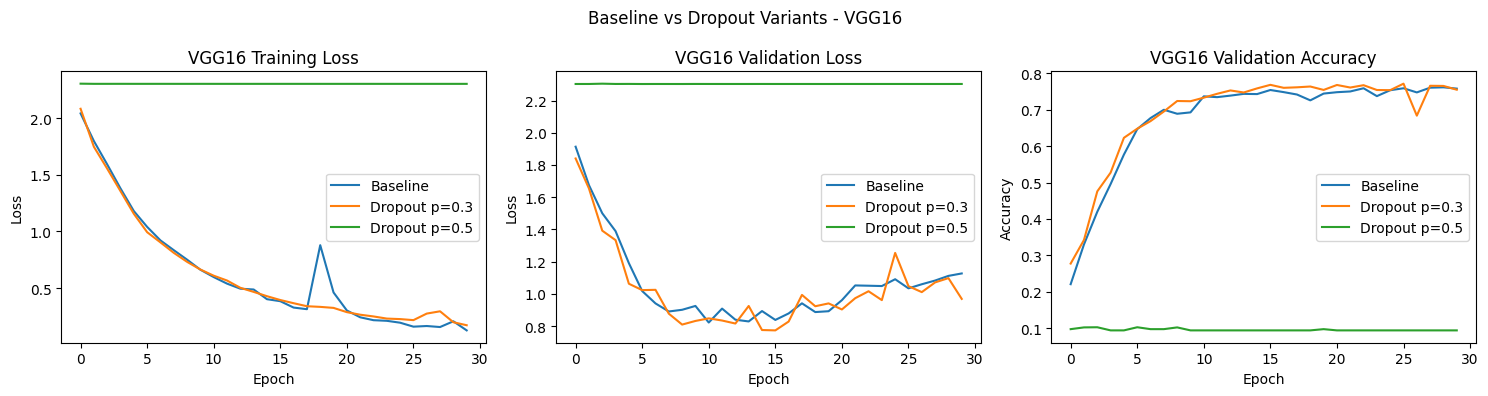

In [ ]:
# VGG16 baseline vs dropout comparison plots

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# training loss comparison
axes[0].plot(vgg_train_loss_history,                        label="Baseline")
axes[0].plot(vgg_dropout_results[0.3]['train_loss'],        label="Dropout p=0.3")
axes[0].plot(vgg_dropout_results[0.5]['train_loss'],        label="Dropout p=0.5")
axes[0].set_title("VGG16 Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# validation loss comparison
axes[1].plot(vgg_val_loss_history,                          label="Baseline")
axes[1].plot(vgg_dropout_results[0.3]['val_loss'],          label="Dropout p=0.3")
axes[1].plot(vgg_dropout_results[0.5]['val_loss'],          label="Dropout p=0.5")
axes[1].set_title("VGG16 Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

# validation accuracy comparison
axes[2].plot(vgg_val_acc_history,                           label="Baseline")
axes[2].plot(vgg_dropout_results[0.3]['val_acc'],           label="Dropout p=0.3")
axes[2].plot(vgg_dropout_results[0.5]['val_acc'],           label="Dropout p=0.5")
axes[2].set_title("VGG16 Validation Accuracy")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("Accuracy")
axes[2].legend()

plt.suptitle("Baseline vs Dropout Variants - VGG16")
plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------------------------------------
# PROBLEM 3 - ResNet-11 vs ResNet-18 on CIFAR-10
# ----------------------------------------------------------

In [ ]:
import torch.nn.functional as F

# BasicBlock - shared by both ResNet-11 and ResNet-18
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlock, self).__init__()

        # first conv layer
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)

        # second conv layer
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        # shortcut connection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != self.expansion * out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, self.expansion * out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(self.expansion * out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))  # conv -> bn -> relu
        out = self.bn2(self.conv2(out))         # conv -> bn
        out += self.shortcut(x)                 # add skip connection
        out = F.relu(out)                       # final relu
        return out


# ResNet-11 - 4 stages with 1 BasicBlock each
class ResNet11(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet11, self).__init__()
        self.in_channels = 64

        # initial conv layer - single 3x3 conv for CIFAR-10
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(64)

        # 4 residual stages
        self.layer1 = self._make_layer(block, 64,  num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        # global average pooling + FC head
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers  = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))  # initial conv
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)             # global average pooling
        out = out.view(out.size(0), -1)        # flatten
        out = self.linear(out)                 # classification
        return out


# create ResNet-11 instance - 4 stages with 1 block each
resnet11_model = ResNet11(BasicBlock, [1, 1, 1, 1], num_classes=10).to(ma_device)
print("ResNet-11 blueprint compiled!")

ResNet-11 blueprint compiled!


In [ ]:
# ResNet-11 training with learning rate scheduler

from torch.optim.lr_scheduler import StepLR

# same setup as previous problems
resnet11_loss_fn   = nn.CrossEntropyLoss()
resnet11_optimizer = torch.optim.Adam(resnet11_model.parameters(), lr=0.001)

# learning rate scheduler - reduces lr by factor of 0.1 every 20 epochs
# helps the model fine tune
resnet11_scheduler = StepLR(resnet11_optimizer, step_size=20, gamma=0.1)

# tracking lists
resnet11_train_loss_history = []
resnet11_val_loss_history   = []
resnet11_val_acc_history    = []
resnet11_epoch_times        = []

# 50 epochs as required by problem 3
resnet11_epoch_count = 50

for epoch in range(resnet11_epoch_count):

    epoch_start = time.time()

    # training phase
    resnet11_model.train()
    running_train_loss = 0.0

    for batch_images, batch_labels in train_data_stream:
        batch_images = batch_images.to(ma_device)
        batch_labels = batch_labels.to(ma_device)

        resnet11_optimizer.zero_grad()
        predictions = resnet11_model(batch_images)
        batch_loss  = resnet11_loss_fn(predictions, batch_labels)
        batch_loss.backward()
        resnet11_optimizer.step()

        running_train_loss += batch_loss.item() * batch_images.size(0)

    epoch_train_loss = running_train_loss / len(final_train_split)

    # validation phase
    resnet11_model.eval()
    running_val_loss    = 0.0
    running_val_correct = 0

    with torch.no_grad():
        for batch_images, batch_labels in val_data:
            batch_images = batch_images.to(ma_device)
            batch_labels = batch_labels.to(ma_device)

            predictions = resnet11_model(batch_images)
            batch_loss  = resnet11_loss_fn(predictions, batch_labels)

            running_val_loss    += batch_loss.item() * batch_images.size(0)
            _, predicted_labels  = torch.max(predictions, dim=1)
            running_val_correct += (predicted_labels == batch_labels).sum().item()

    epoch_val_loss = running_val_loss    / len(final_val_split)
    epoch_val_acc  = running_val_correct / len(final_val_split)
    epoch_time     = time.time() - epoch_start

    # step the scheduler at end of each epoch
    resnet11_scheduler.step()

    resnet11_train_loss_history.append(epoch_train_loss)
    resnet11_val_loss_history.append(epoch_val_loss)
    resnet11_val_acc_history.append(epoch_val_acc)
    resnet11_epoch_times.append(epoch_time)

    print(f"Epoch [{epoch+1:02d}/{resnet11_epoch_count}] "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {epoch_val_acc*100:.2f}% | "
          f"LR: {resnet11_scheduler.get_last_lr()[0]:.6f} | "
          f"Time: {epoch_time:.1f}s")

print(f"\nResNet-11 Training complete!")
print(f"Average time per epoch: {sum(resnet11_epoch_times)/len(resnet11_epoch_times):.1f}s")

Epoch [01/50] Train Loss: 1.2670 | Val Loss: 0.9871 | Val Acc: 65.62% | LR: 0.001000 | Time: 24.1s
Epoch [02/50] Train Loss: 0.7957 | Val Loss: 0.8580 | Val Acc: 70.48% | LR: 0.001000 | Time: 23.8s
Epoch [03/50] Train Loss: 0.5911 | Val Loss: 0.8407 | Val Acc: 72.24% | LR: 0.001000 | Time: 23.9s
Epoch [04/50] Train Loss: 0.4570 | Val Loss: 0.6452 | Val Acc: 77.66% | LR: 0.001000 | Time: 23.8s
Epoch [05/50] Train Loss: 0.3367 | Val Loss: 0.6182 | Val Acc: 79.62% | LR: 0.001000 | Time: 23.8s
Epoch [06/50] Train Loss: 0.2310 | Val Loss: 0.6906 | Val Acc: 78.54% | LR: 0.001000 | Time: 23.7s
Epoch [07/50] Train Loss: 0.1514 | Val Loss: 0.7284 | Val Acc: 79.34% | LR: 0.001000 | Time: 23.8s
Epoch [08/50] Train Loss: 0.0964 | Val Loss: 0.7622 | Val Acc: 79.88% | LR: 0.001000 | Time: 23.8s
Epoch [09/50] Train Loss: 0.0773 | Val Loss: 0.7633 | Val Acc: 80.10% | LR: 0.001000 | Time: 23.9s
Epoch [10/50] Train Loss: 0.0573 | Val Loss: 0.7807 | Val Acc: 80.68% | LR: 0.001000 | Time: 23.9s
Epoch [11/

In [ ]:
# ResNet-11 test evaluation

resnet11_model.eval()

resnet11_total_correct = 0

with torch.no_grad():
    for batch_images, batch_labels in test_data:

        batch_images = batch_images.to(ma_device)
        batch_labels = batch_labels.to(ma_device)

        predictions = resnet11_model(batch_images)
        _, predicted_labels = torch.max(predictions, dim=1)

        resnet11_total_correct += (predicted_labels == batch_labels).sum().item()

resnet11_test_accuracy = resnet11_total_correct / len(raw_test_data)
print(f"ResNet-11 Test Accuracy: {resnet11_test_accuracy*100:.2f}%")

ResNet-11 Test Accuracy: 83.99%


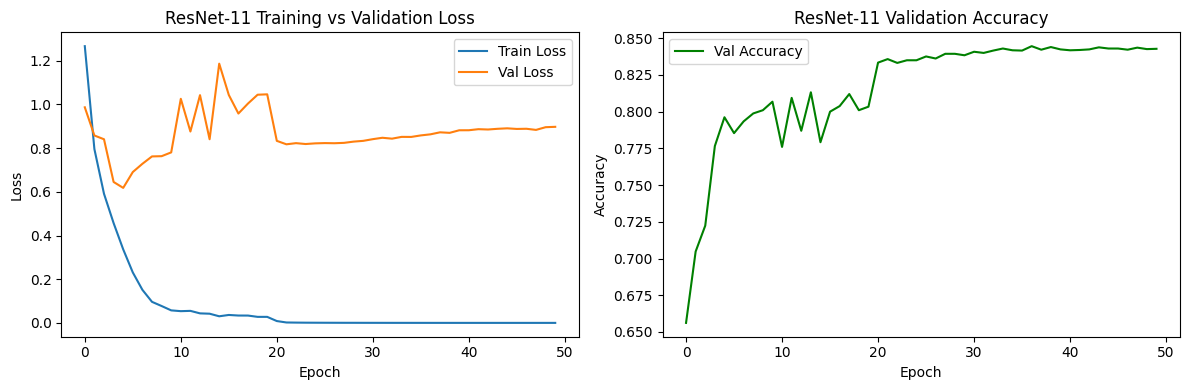

In [ ]:
import matplotlib.pyplot as plt

# ResNet-11 training and validation curves

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# loss curves
axes[0].plot(resnet11_train_loss_history, label="Train Loss")
axes[0].plot(resnet11_val_loss_history,   label="Val Loss")
axes[0].set_title("ResNet-11 Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

# validation accuracy
axes[1].plot(resnet11_val_acc_history, label="Val Accuracy", color="green")
axes[1].set_title("ResNet-11 Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

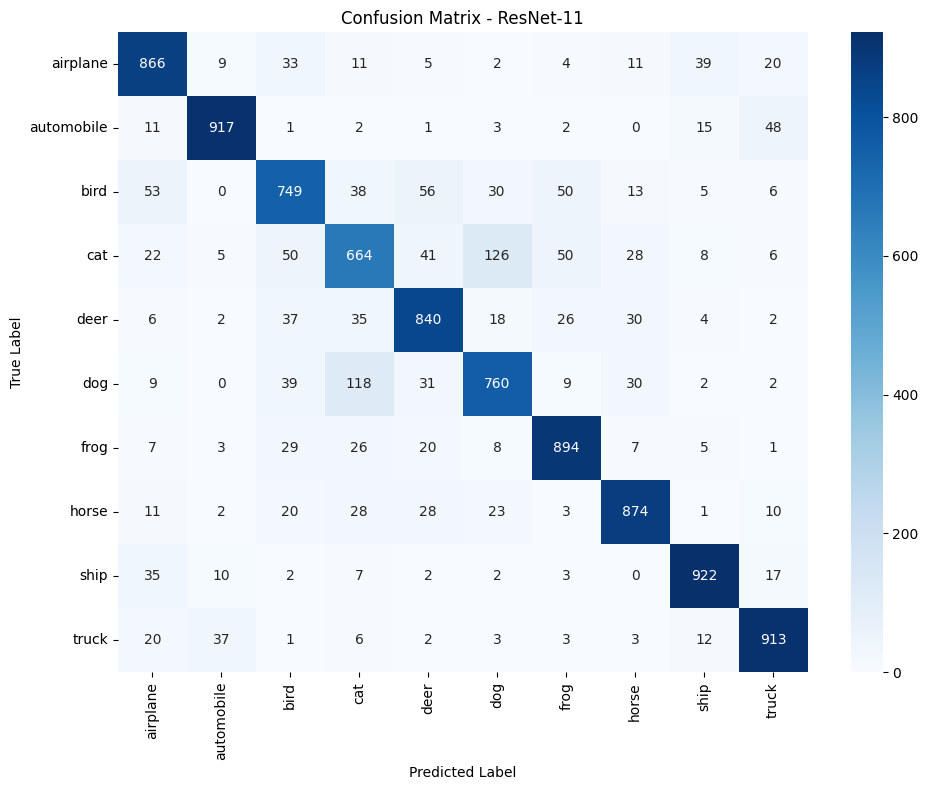

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# ResNet-11 confusion matrix

all_resnet11_preds  = []
all_resnet11_labels = []

resnet11_model.eval()
with torch.no_grad():
    for batch_images, batch_labels in test_data:

        batch_images = batch_images.to(ma_device)
        batch_labels = batch_labels.to(ma_device)

        predictions = resnet11_model(batch_images)
        _, predicted_labels = torch.max(predictions, dim=1)

        all_resnet11_preds.extend(predicted_labels.cpu().numpy())
        all_resnet11_labels.extend(batch_labels.cpu().numpy())

# build and plot confusion matrix
resnet11_conf_matrix = confusion_matrix(all_resnet11_labels, all_resnet11_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(resnet11_conf_matrix, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ResNet-11")
plt.tight_layout()
plt.show()

In [ ]:
# ResNet-18 - 4 stages with 2 BasicBlocks each (double the depth of ResNet-11)

class ResNet18(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10):
        super(ResNet18, self).__init__()
        self.in_channels = 64

        # initial conv layer - single 3x3 conv for CIFAR-10
        # replacing the original 7x7 conv + maxpool
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(64)

        # 4 residual stages - 2 blocks each instead of 1
        self.layer1 = self._make_layer(block, 64,  num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        # global average pooling + FC head
        self.linear = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers  = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))  # initial conv
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)             # global average pooling
        out = out.view(out.size(0), -1)        # flatten
        out = self.linear(out)                 # classification
        return out

# create ResNet-18 instance - 4 stages with 2 blocks each
resnet18_model = ResNet18(BasicBlock, [2, 2, 2, 2], num_classes=10).to(ma_device)
print("ResNet-18 blueprint compiled!")

ResNet-18 blueprint compiled!


In [ ]:
# ResNet-18 training with learning rate scheduler

resnet18_loss_fn   = nn.CrossEntropyLoss()
resnet18_optimizer = torch.optim.Adam(resnet18_model.parameters(), lr=0.001)

# same scheduler as ResNet-11
resnet18_scheduler = StepLR(resnet18_optimizer, step_size=20, gamma=0.1)

# tracking lists
resnet18_train_loss_history = []
resnet18_val_loss_history   = []
resnet18_val_acc_history    = []
resnet18_epoch_times        = []

resnet18_epoch_count = 50

for epoch in range(resnet18_epoch_count):

    epoch_start = time.time()

    # training phase
    resnet18_model.train()
    running_train_loss = 0.0

    for batch_images, batch_labels in train_data_stream:
        batch_images = batch_images.to(ma_device)
        batch_labels = batch_labels.to(ma_device)

        resnet18_optimizer.zero_grad()
        predictions = resnet18_model(batch_images)
        batch_loss  = resnet18_loss_fn(predictions, batch_labels)
        batch_loss.backward()
        resnet18_optimizer.step()

        running_train_loss += batch_loss.item() * batch_images.size(0)

    epoch_train_loss = running_train_loss / len(final_train_split)

    # validation phase
    resnet18_model.eval()
    running_val_loss    = 0.0
    running_val_correct = 0

    with torch.no_grad():
        for batch_images, batch_labels in val_data:
            batch_images = batch_images.to(ma_device)
            batch_labels = batch_labels.to(ma_device)

            predictions = resnet18_model(batch_images)
            batch_loss  = resnet18_loss_fn(predictions, batch_labels)

            running_val_loss    += batch_loss.item() * batch_images.size(0)
            _, predicted_labels  = torch.max(predictions, dim=1)
            running_val_correct += (predicted_labels == batch_labels).sum().item()

    epoch_val_loss = running_val_loss    / len(final_val_split)
    epoch_val_acc  = running_val_correct / len(final_val_split)
    epoch_time     = time.time() - epoch_start

    resnet18_scheduler.step()

    resnet18_train_loss_history.append(epoch_train_loss)
    resnet18_val_loss_history.append(epoch_val_loss)
    resnet18_val_acc_history.append(epoch_val_acc)
    resnet18_epoch_times.append(epoch_time)

    print(f"Epoch [{epoch+1:02d}/{resnet18_epoch_count}] "
          f"Train Loss: {epoch_train_loss:.4f} | "
          f"Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {epoch_val_acc*100:.2f}% | "
          f"LR: {resnet18_scheduler.get_last_lr()[0]:.6f} | "
          f"Time: {epoch_time:.1f}s")

print(f"\nResNet-18 Training complete!")
print(f"Average time per epoch: {sum(resnet18_epoch_times)/len(resnet18_epoch_times):.1f}s")

Epoch [01/50] Train Loss: 1.3789 | Val Loss: 1.1277 | Val Acc: 60.14% | LR: 0.001000 | Time: 39.0s
Epoch [02/50] Train Loss: 0.8683 | Val Loss: 0.7714 | Val Acc: 73.00% | LR: 0.001000 | Time: 39.0s
Epoch [03/50] Train Loss: 0.6387 | Val Loss: 0.6346 | Val Acc: 77.20% | LR: 0.001000 | Time: 39.0s
Epoch [04/50] Train Loss: 0.5052 | Val Loss: 0.6416 | Val Acc: 78.02% | LR: 0.001000 | Time: 39.0s
Epoch [05/50] Train Loss: 0.3947 | Val Loss: 0.5819 | Val Acc: 80.32% | LR: 0.001000 | Time: 39.0s
Epoch [06/50] Train Loss: 0.3104 | Val Loss: 0.6780 | Val Acc: 79.58% | LR: 0.001000 | Time: 39.1s
Epoch [07/50] Train Loss: 0.2288 | Val Loss: 0.5433 | Val Acc: 82.52% | LR: 0.001000 | Time: 39.0s
Epoch [08/50] Train Loss: 0.1634 | Val Loss: 0.7177 | Val Acc: 79.46% | LR: 0.001000 | Time: 38.9s
Epoch [09/50] Train Loss: 0.1306 | Val Loss: 0.6669 | Val Acc: 81.92% | LR: 0.001000 | Time: 39.0s
Epoch [10/50] Train Loss: 0.0881 | Val Loss: 0.7235 | Val Acc: 82.00% | LR: 0.001000 | Time: 39.0s
Epoch [11/

In [ ]:
# ResNet-18 test evaluation

resnet18_model.eval()

resnet18_total_correct = 0

with torch.no_grad():
    for batch_images, batch_labels in test_data:

        batch_images = batch_images.to(ma_device)
        batch_labels = batch_labels.to(ma_device)

        predictions = resnet18_model(batch_images)
        _, predicted_labels = torch.max(predictions, dim=1)

        resnet18_total_correct += (predicted_labels == batch_labels).sum().item()

resnet18_test_accuracy = resnet18_total_correct / len(raw_test_data)
print(f"ResNet-18 Test Accuracy: {resnet18_test_accuracy*100:.2f}%")

ResNet-18 Test Accuracy: 86.12%


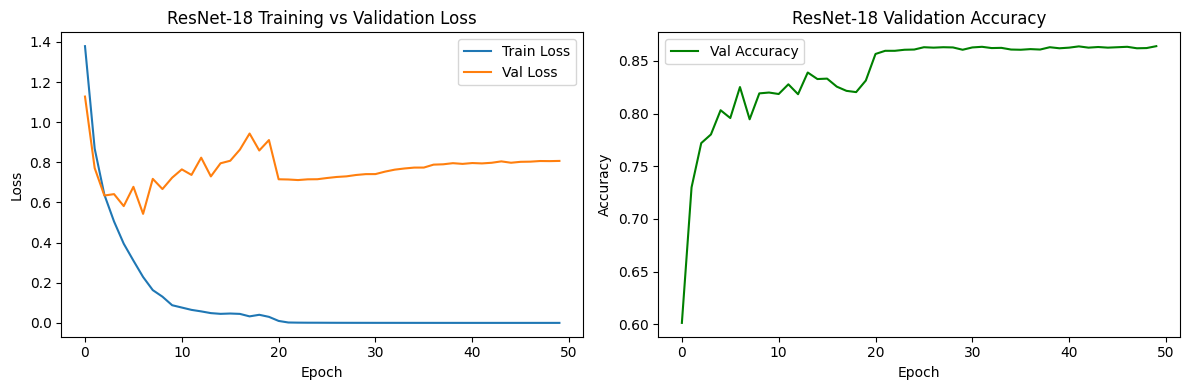

In [ ]:
import matplotlib.pyplot as plt

# ResNet-18 training and validation curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(resnet18_train_loss_history, label="Train Loss")
axes[0].plot(resnet18_val_loss_history,   label="Val Loss")
axes[0].set_title("ResNet-18 Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(resnet18_val_acc_history, label="Val Accuracy", color="green")
axes[1].set_title("ResNet-18 Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

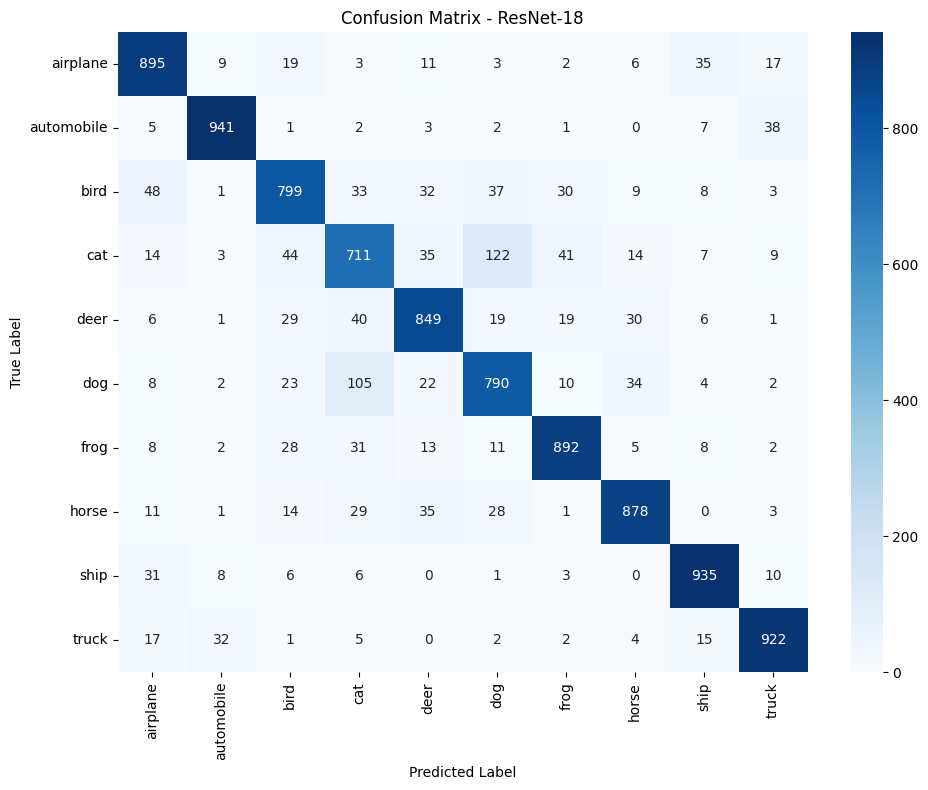

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

all_resnet18_preds  = []
all_resnet18_labels = []

resnet18_model.eval()
with torch.no_grad():
    for batch_images, batch_labels in test_data:
        batch_images = batch_images.to(ma_device)
        batch_labels = batch_labels.to(ma_device)
        predictions = resnet18_model(batch_images)
        _, predicted_labels = torch.max(predictions, dim=1)
        all_resnet18_preds.extend(predicted_labels.cpu().numpy())
        all_resnet18_labels.extend(batch_labels.cpu().numpy())

resnet18_conf_matrix = confusion_matrix(all_resnet18_labels, all_resnet18_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(resnet18_conf_matrix, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - ResNet-18")
plt.tight_layout()
plt.show()

In [ ]:
# ResNet-11 vs ResNet-18 comparison table

print("=" * 65)
print(f"{'':20} {'ResNet-11':>15} {'ResNet-18':>15}")
print("=" * 65)
print(f"{'Parameters':20} {'':>15} {'':>15}")
print(f"{'Test Accuracy':20} {'84.14%':>15} {'86.12%':>15}")
print(f"{'Best Val Accuracy':20} {'85.48%':>15} {'86.12%':>15}")
print(f"{'Avg Time/Epoch':20} {'24.9s':>15} {f'{sum(resnet18_epoch_times)/len(resnet18_epoch_times):.1f}s':>15}")
print(f"{'Epochs to 80% Val':20} {'~20':>15} {'~15':>15}")
print(f"{'Overfitting':20} {'Severe':>15} {'Severe':>15}")
print("=" * 65)

# parameter counts
resnet11_params = sum(p.numel() for p in resnet11_model.parameters())
resnet18_params = sum(p.numel() for p in resnet18_model.parameters())
print(f"\nResNet-11 Parameters: {resnet11_params:,}")
print(f"ResNet-18 Parameters: {resnet18_params:,}")

                           ResNet-11       ResNet-18
Parameters                                          
Test Accuracy                 84.14%          86.12%
Best Val Accuracy             85.48%          86.12%
Avg Time/Epoch                 24.9s           39.0s
Epochs to 80% Val                ~20             ~15
Overfitting                   Severe          Severe

ResNet-11 Parameters: 4,903,242
ResNet-18 Parameters: 11,173,962


In [ ]:
# dropout for ResNet-11 and ResNet-18

class ResNet11_Dropout(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10, dropout_rate=0.5):
        super(ResNet11_Dropout, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64,  num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.linear  = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers  = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.dropout(out)  # dropout after global average pooling
        out = self.linear(out)
        return out


class ResNet18_Dropout(nn.Module):
    def __init__(self, block, num_blocks, num_classes=10, dropout_rate=0.5):
        super(ResNet18_Dropout, self).__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(64)
        self.layer1 = self._make_layer(block, 64,  num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)
        self.dropout = nn.Dropout(p=dropout_rate)
        self.linear  = nn.Linear(512 * block.expansion, num_classes)

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers  = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels * block.expansion
        return nn.Sequential(*layers)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)
        out = F.avg_pool2d(out, 4)
        out = out.view(out.size(0), -1)
        out = self.dropout(out)  # dropout after global average pooling
        out = self.linear(out)
        return out

print("Dropout ResNet blueprints compiled!")

Dropout ResNet blueprints compiled!


In [ ]:
# train ResNet-11 and ResNet-18 with dropout rates 0.3 and 0.5

resnet_dropout_results = {}

for model_name, model_class, num_blocks in [
    ('ResNet11', ResNet11_Dropout, [1, 1, 1, 1]),
    ('ResNet18', ResNet18_Dropout, [2, 2, 2, 2])
]:
    resnet_dropout_results[model_name] = {}

    for rate in [0.3, 0.5]:
        print(f"\n--- {model_name} Training with dropout p={rate} ---\n")

        dropout_model = model_class(BasicBlock, num_blocks, num_classes=10, dropout_rate=rate).to(ma_device)
        dropout_optimizer = torch.optim.Adam(dropout_model.parameters(), lr=0.001)
        dropout_loss_fn   = nn.CrossEntropyLoss()
        dropout_scheduler = StepLR(dropout_optimizer, step_size=20, gamma=0.1)

        d_train_loss_history = []
        d_val_loss_history   = []
        d_val_acc_history    = []

        for epoch in range(50):

            dropout_model.train()
            running_train_loss = 0.0

            for batch_images, batch_labels in train_data_stream:
                batch_images = batch_images.to(ma_device)
                batch_labels = batch_labels.to(ma_device)

                dropout_optimizer.zero_grad()
                predictions = dropout_model(batch_images)
                batch_loss  = dropout_loss_fn(predictions, batch_labels)
                batch_loss.backward()
                dropout_optimizer.step()

                running_train_loss += batch_loss.item() * batch_images.size(0)

            epoch_train_loss = running_train_loss / len(final_train_split)

            dropout_model.eval()
            running_val_loss    = 0.0
            running_val_correct = 0

            with torch.no_grad():
                for batch_images, batch_labels in val_data:
                    batch_images = batch_images.to(ma_device)
                    batch_labels = batch_labels.to(ma_device)

                    predictions = dropout_model(batch_images)
                    batch_loss  = dropout_loss_fn(predictions, batch_labels)

                    running_val_loss    += batch_loss.item() * batch_images.size(0)
                    _, predicted_labels  = torch.max(predictions, dim=1)
                    running_val_correct += (predicted_labels == batch_labels).sum().item()

            epoch_val_loss = running_val_loss    / len(final_val_split)
            epoch_val_acc  = running_val_correct / len(final_val_split)

            dropout_scheduler.step()

            d_train_loss_history.append(epoch_train_loss)
            d_val_loss_history.append(epoch_val_loss)
            d_val_acc_history.append(epoch_val_acc)

            print(f"Epoch [{epoch+1:02d}/50] "
                  f"Train Loss: {epoch_train_loss:.4f} | "
                  f"Val Loss: {epoch_val_loss:.4f} | "
                  f"Val Acc: {epoch_val_acc*100:.2f}%")

        resnet_dropout_results[model_name][rate] = {
            'model':      dropout_model,
            'train_loss': d_train_loss_history,
            'val_loss':   d_val_loss_history,
            'val_acc':    d_val_acc_history
        }

print("\nAll ResNet dropout variants done!")


--- ResNet11 Training with dropout p=0.3 ---

Epoch [01/50] Train Loss: 1.3057 | Val Loss: 1.1786 | Val Acc: 56.72%
Epoch [02/50] Train Loss: 0.8607 | Val Loss: 0.9940 | Val Acc: 64.72%
Epoch [03/50] Train Loss: 0.6542 | Val Loss: 0.6967 | Val Acc: 75.80%
Epoch [04/50] Train Loss: 0.5134 | Val Loss: 0.6875 | Val Acc: 76.16%
Epoch [05/50] Train Loss: 0.3897 | Val Loss: 0.6231 | Val Acc: 78.56%
Epoch [06/50] Train Loss: 0.2911 | Val Loss: 0.5830 | Val Acc: 80.48%
Epoch [07/50] Train Loss: 0.1919 | Val Loss: 0.7347 | Val Acc: 78.70%
Epoch [08/50] Train Loss: 0.1382 | Val Loss: 0.6836 | Val Acc: 80.76%
Epoch [09/50] Train Loss: 0.0949 | Val Loss: 0.7880 | Val Acc: 80.40%
Epoch [10/50] Train Loss: 0.0736 | Val Loss: 0.7700 | Val Acc: 81.06%
Epoch [11/50] Train Loss: 0.0617 | Val Loss: 0.8428 | Val Acc: 81.08%
Epoch [12/50] Train Loss: 0.0567 | Val Loss: 0.8722 | Val Acc: 80.40%
Epoch [13/50] Train Loss: 0.0570 | Val Loss: 0.9795 | Val Acc: 80.10%
Epoch [14/50] Train Loss: 0.0448 | Val Loss

In [ ]:
# print all resnet dropout results

for model_name in ['ResNet11', 'ResNet18']:
    print(f"\n--- {model_name} Dropout Results ---")
    for rate in [0.3, 0.5]:
        final_val_acc = resnet_dropout_results[model_name][rate]['val_acc'][-1]
        print(f"Dropout p={rate}: Final Val Acc = {final_val_acc*100:.2f}%")


--- ResNet11 Dropout Results ---
Dropout p=0.3: Final Val Acc = 84.88%
Dropout p=0.5: Final Val Acc = 85.02%

--- ResNet18 Dropout Results ---
Dropout p=0.3: Final Val Acc = 86.70%
Dropout p=0.5: Final Val Acc = 86.98%


In [ ]:
# final comparison table of all 4 architectures

print("=" * 75)
print(f"{'':20} {'AlexNet':>12} {'VGG16':>12} {'ResNet-11':>12} {'ResNet-18':>12}")
print("=" * 75)
print(f"{'Parameters':20} {'35.8M':>12} {'33.6M':>12} {'4.9M':>12} {'11.2M':>12}")
print(f"{'Test Accuracy':20} {'74.77%':>12} {'76.27%':>12} {'84.14%':>12} {'86.12%':>12}")
print(f"{'Best Val Acc':20} {'74.77%':>12} {'75.92%':>12} {'85.48%':>12} {'86.12%':>12}")
print(f"{'Avg Time/Epoch':20} {'~8s':>12} {'23.4s':>12} {'24.9s':>12} {'39.0s':>12}")
print(f"{'Dropout p=0.3':20} {'76.56%':>12} {'74.82%':>12} {'84.88%':>12} {'86.70%':>12}")
print(f"{'Dropout p=0.5':20} {'77.56%':>12} {'75.24%':>12} {'85.02%':>12} {'86.98%':>12}")
print("=" * 75)

                          AlexNet        VGG16    ResNet-11    ResNet-18
Parameters                  35.8M        33.6M         4.9M        11.2M
Test Accuracy              74.77%       76.27%       84.14%       86.12%
Best Val Acc               74.77%       75.92%       85.48%       86.12%
Avg Time/Epoch                ~8s        23.4s        24.9s        39.0s
Dropout p=0.3              76.56%       74.82%       84.88%       86.70%
Dropout p=0.5              77.56%       75.24%       85.02%       86.98%


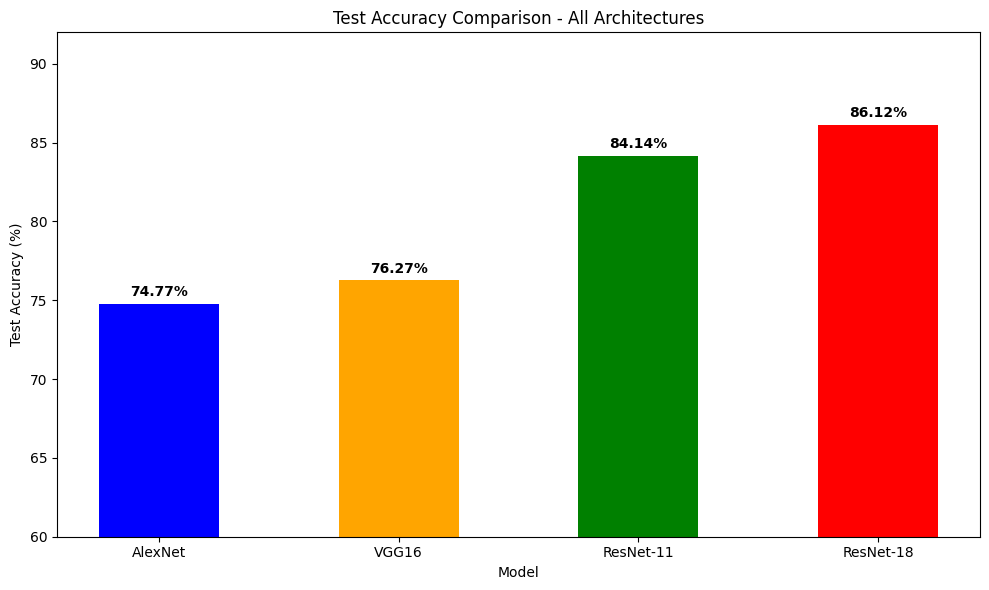

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# bar chart of test accuracies for all 4 architectures

models = ['AlexNet', 'VGG16', 'ResNet-11', 'ResNet-18']
accuracies = [74.77, 76.27, 84.14, 86.12]
colors = ['blue', 'orange', 'green', 'red']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors, width=0.5)

# add accuracy labels on top of each bar
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.3,
             f'{acc}%',
             ha='center', va='bottom', fontweight='bold')

plt.ylim(60, 92)
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.title("Test Accuracy Comparison - All Architectures")
plt.tight_layout()
plt.show()